In [129]:
import pandas as pd
import numpy as np

In [130]:
# data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv"

In [131]:
# !wget $data

## **Data Preparation**

In [132]:
df = pd.read_csv('data.csv')

In [133]:
df.head(3)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350


Check the feature names if they are consistent. (lower case, using -, etc)

In [134]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [135]:
df.head(3)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350


Checking the value of each feature

- Just like in the feature names, you have to standardize the value of each feature. Convert all of them to lowercase, and replace space with _

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  object 
 1   model              11914 non-null  object 
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11911 non-null  object 
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  object 
 7   driven_wheels      11914 non-null  object 
 8   number_of_doors    11908 non-null  float64
 9   market_category    8172 non-null   object 
 10  vehicle_size       11914 non-null  object 
 11  vehicle_style      11914 non-null  object 
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5

In [137]:
strings_column = list(df.dtypes[df.dtypes == 'object'].index)
strings_column

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [138]:
for i in strings_column:
    df[i] = df[i].str.lower().str.replace(' ', '_')

In [139]:
df.head(3)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350


## **Exploratory Data Analysis**

1. **Checking all the unique values per feature**

In [140]:
for i in df.columns:
    print(i)
    print(df[i].unique()[:5])
    print(df[i].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

2. **Checking the distribution**

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Distribution of msrp

<Axes: xlabel='msrp', ylabel='Count'>

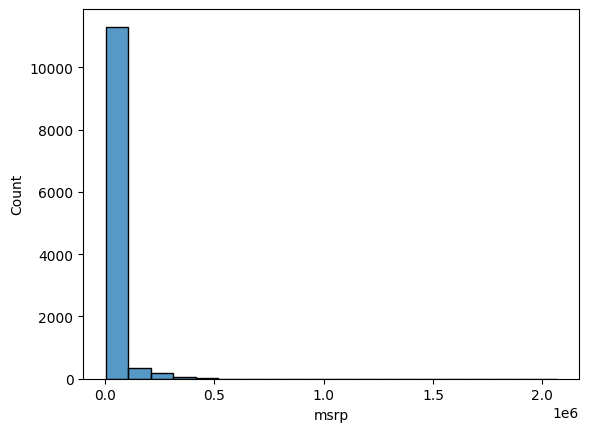

In [142]:
sns.histplot(df.msrp, bins=20)

It seems to be a long tail distribution

<Axes: xlabel='msrp', ylabel='Count'>

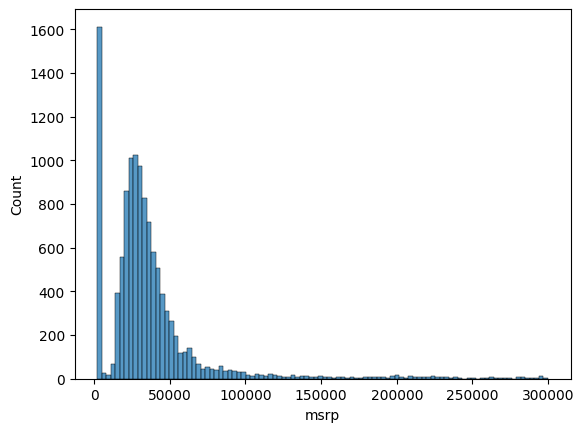

In [143]:
sns.histplot(df.msrp[df.msrp < 300000], bins=100)

This kind of distribution is not good for machine learning. As much as possible, it have a normal distributio

**Applying Logarithm for value change**

In [144]:
# example
np.log([1,10,100,1000])

array([0.        , 2.30258509, 4.60517019, 6.90775528])

In [145]:
# you cannot process 0, thus you need to add 1 for all of them
np.log1p([0, 10, 100, 10000])

array([0.        , 2.39789527, 4.61512052, 9.21044037])

In [146]:
price_logs = np.log1p(df.msrp)
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

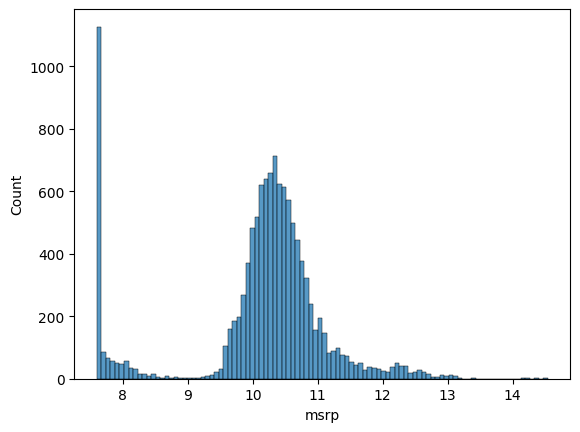

In [147]:
## Checking its distribution

sns.histplot(price_logs, bins=100)

3. **Looking at the missing values**

In [148]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## **Validation Framework**

train = 60%
validation = 20%
test = 20%

In [149]:
n = len(df)

n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n-n_test-n_val

In [150]:
n, n_val, n_test, n_train

(11914, 2382, 2382, 7150)

**Reshuffle the dataframe**
- You can reshuffle the dataframe by shuffling its index using numpy

In [151]:
index = np.arange(n)

In [152]:
index

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [153]:
np.random.seed(5)
np.random.shuffle(index)

In [154]:
index

array([3863, 7113,  917, ..., 4079, 2254, 2915], shape=(11914,))

In [155]:
df_train = df.iloc[index[:n_train]]
df_val = df.iloc[index[n_train:n_train+n_val]]
df_test = df.iloc[index[n_val+n_train:]]

In [156]:
df_train.shape, df_val.shape, df_test.shape

((7150, 16), (2382, 16), (2382, 16))

Resetting and Removing the index

In [157]:
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [158]:
df_test.msrp

0        4107
1       24995
2       16799
3       43605
4       26830
        ...  
2377    27870
2378     2000
2379    68500
2380    23070
2381     2000
Name: msrp, Length: 2382, dtype: int64

**Transforming the target variable that should be usable for machine learning**

transform the msrp to logarithmic scale and put it inside a variable (array)

In [159]:
y_train = np.log1p(df_train.msrp.values)
y_test = np.log1p(df_test.msrp.values)
y_val = np.log1p(df_val.msrp.values)

In [160]:
y_val

array([10.61277871, 11.01495025, 10.89518256, ...,  7.63964229,
        9.83633228,  7.60140233], shape=(2382,))

Delete the target variable from the dataframe. 

In [161]:
del df_train['msrp']
del df_test['msrp']
del df_val['msrp']

## **Linear Regression**

In [162]:
df.iloc[10]

make                                         bmw
model                                   1_series
year                                        2013
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  300.0
engine_cylinders                             6.0
transmission_type                         manual
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category          luxury,high-performance
vehicle_size                             compact
vehicle_style                              coupe
highway_mpg                                   28
city_mpg                                      20
popularity                                  3916
msrp                                       39600
Name: 10, dtype: object

In [163]:
# putting random bias and weights without calculation 
w0 = 7
w = [0.7,0.25,0.05]

In [164]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred    

Trying out the simple model

In [165]:
# features: year, engine in hp, miles per galloon
xi = [2013, 300, 20]

linear_regression(xi)

1492.1

It seems the car would cost 1,492.1 USD. 

## **Linear Regression Vector Form**

Multiple row at the same time (Check written notes)

In [166]:
def dot(xi, w):
    n = len(xi)

    res = w0

    for j in range(n):
        res = res + w[j] * xi[j]

    return res    

In [167]:
w_new = [w0]+w
w_new

[7, 0.7, 0.25, 0.05]

In [168]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [169]:
linear_regression(xi)

1499.1

In [170]:
xi = [2025, 11, 86]
w0 = 1.1
w = [0.01, 0.04, 0.0045]
w_new = [w0] + w

In [171]:
w_new

[1.1, 0.01, 0.04, 0.0045]

In [172]:
x1 = [1, 2010,3,199]
x2 = [1,2020,11, 198983]
x10= [1, 2019, 10, 500]

X=[x1,x2,x10]
X = np.array(X)
X

array([[     1,   2010,      3,    199],
       [     1,   2020,     11, 198983],
       [     1,   2019,     10,    500]])

In [173]:
X.dot(w_new)

array([ 22.2155, 917.1635,  23.94  ])

More simplified form of linear regresion

In [174]:
def linear_regression(X):
    return X.dot(w_new)

In [175]:
linear_regression(X)

array([ 22.2155, 917.1635,  23.94  ])

### **Training a linear regression model**

In [176]:
X = [
[ 2010,3,199],
[2020,11, 198983],
[ 2019, 10, 500],
[ 2010,3,199],
[2020,11, 198983],
[ 2019, 10, 500],
[ 2010,3,199],
[2020,11, 198983],
[ 2019, 10, 500]
]

X = np.array(X)
X

array([[  2010,      3,    199],
       [  2020,     11, 198983],
       [  2019,     10,    500],
       [  2010,      3,    199],
       [  2020,     11, 198983],
       [  2019,     10,    500],
       [  2010,      3,    199],
       [  2020,     11, 198983],
       [  2019,     10,    500]])

In [177]:
XTX = X.T.dot(X) # gram matrix
XTX

array([[    36590583,       145320,   1210065450],
       [      145320,          690,      6583230],
       [  1210065450,      6583230, 118783571670]])

In [178]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 1.84200108e-07, -4.43333170e-05,  5.80570487e-10],
       [-4.43333170e-05,  1.37457130e-02, -3.10185781e-07],
       [ 5.80570487e-10, -3.10185781e-07,  1.96954513e-11]])

In [179]:
XTX.dot(XTX_inv)

array([[1.00000000e+00, 8.34444330e-14, 1.88036519e-19],
       [4.39368232e-18, 1.00000000e+00, 2.46211214e-20],
       [0.00000000e+00, 1.45519152e-11, 1.00000000e+00]])

In [180]:
y = [1313,1353,8592,1313,1353,8592,1313,1353,8592]

In [181]:
w = XTX_inv.dot(X.T).dot(y)

In [182]:
w

array([-8.99064068e-01,  1.04280709e+03, -4.17209938e-02])

1. Adding bias term to X

In [183]:
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])
X 

array([[1.00000e+00, 2.01000e+03, 3.00000e+00, 1.99000e+02],
       [1.00000e+00, 2.02000e+03, 1.10000e+01, 1.98983e+05],
       [1.00000e+00, 2.01900e+03, 1.00000e+01, 5.00000e+02],
       [1.00000e+00, 2.01000e+03, 3.00000e+00, 1.99000e+02],
       [1.00000e+00, 2.02000e+03, 1.10000e+01, 1.98983e+05],
       [1.00000e+00, 2.01900e+03, 1.00000e+01, 5.00000e+02],
       [1.00000e+00, 2.01000e+03, 3.00000e+00, 1.99000e+02],
       [1.00000e+00, 2.02000e+03, 1.10000e+01, 1.98983e+05],
       [1.00000e+00, 2.01900e+03, 1.00000e+01, 5.00000e+02]])

2. Solving the weight vectors

In [184]:
XTX = X.T.dot(X) # gram matrix
XTX_inv = np.linalg.inv(XTX)
y = [1313,1353,8592,1313,1353,8592,1313,1353,8592]
w_full = XTX_inv.dot(X.T).dot(y)
w_full

array([-4.52601592e+04,  2.28219610e+01,  1.02156469e+03, -4.17051464e-02])

In [185]:
# assigning based in mathematical formula
w0 = w_full[0] # the first one is the bias term
w = w_full[1:]

In [186]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X) 
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [187]:
# train_linear_regression(X, y)

## **Car price baseline mdel**

In [188]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [189]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

df_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,173.0,4.0,35,24,1439
1,167.0,4.0,28,22,586
2,172.0,6.0,23,17,3105
3,145.0,4.0,37,27,1439
4,155.0,4.0,28,22,481
...,...,...,...,...,...
7145,330.0,6.0,24,17,190
7146,205.0,4.0,29,21,640
7147,321.0,6.0,28,18,1624
7148,210.0,4.0,33,22,873


Checking null because you cannot feed the model with NULL

In [190]:
df_train[base].isnull().sum()

engine_hp           42
engine_cylinders    21
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

For now, convert this null to 0

In [191]:
df_train[base] = df_train[base].fillna(0)

In [192]:
df_train[base].values

array([[ 173.,    4.,   35.,   24., 1439.],
       [ 167.,    4.,   28.,   22.,  586.],
       [ 172.,    6.,   23.,   17., 3105.],
       ...,
       [ 321.,    6.,   28.,   18., 1624.],
       [ 210.,    4.,   33.,   22.,  873.],
       [ 250.,    6.,   21.,   15., 2202.]], shape=(7150, 5))

In [193]:
X_train = df_train[base].values

In [194]:
y_train

array([ 9.96415923, 10.08460005,  7.60140233, ..., 10.77092412,
       10.18191443, 10.33270174], shape=(7150,))

In [195]:
## solve for the w0 and w

w0, w=train_linear_regression(X_train, y_train)

This is the bias term (intercept)

In [196]:
w0

np.float64(7.937391668446512)

These are the different weights of the five features

In [197]:
w

array([ 9.45603074e-03, -1.45172387e-01,  1.58001781e-02,  1.25212560e-02,
       -1.09113412e-05])

Now we can solve for the y_pred, with the formula y = W0 + x (dot) W 

In [198]:
y_pred = w0 +  X_train.dot(w)

In [199]:
y_pred

array([ 9.8304104 ,  9.64733783,  9.23518037, ..., 10.75181079,
       10.12981649,  9.92596084], shape=(7150,))

<Axes: ylabel='Count'>

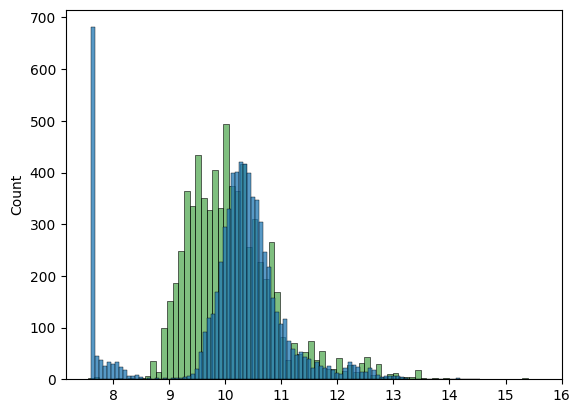

In [200]:
# checking the distribution

sns.histplot(y_pred, color= 'green', alpha=0.5)
sns.histplot(y_train)

Just looking at the plot, we can infer that our created model is not ideal. The predicted y seems to be have lower msrp compare to the expected y.

## **RMSE**

Root Mean Squared Error
- This is the average difference between the predicted value and the actual value that is squared. 

In [201]:
## writing the function based on the formula

def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)


In [202]:
rmse(y_train, y_pred)

np.float64(0.7494783449748382)

### **Validation of the model**

In [203]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

X_train = df_train[base].fillna(0).values

w0, w= train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

In [204]:
# Convert this: X_train = df_train[base].fillna(0).values to a function

def prepare_X(df): # not just df_train or df_test
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [205]:
# Now use that function to create the X training matrix

X_train = prepare_X(df_train)
w0, w= train_linear_regression(X_train, y_train)

# Then, do the same thing but using the validation dataset
X_val = prepare_X(df_val)

# Then, find the predicted values with respect to the validation dataset
y_pred = w0 + X_val.dot(w)

In [206]:
# Since prediction has been made, lets find its RMSE.
rmse(y_val, y_pred)

np.float64(0.7580590021748517)

75% RMSE is bad given that there has been no actual thorough study or research regarding the goal, the problem and the actual dataset.

## **Feature Engineering**

Adding the age of the car, which is very important variable in car-selling business

In [207]:
df_train.year.max()

np.int64(2017)

We can see that the latest year of the dataset is 2017

In [208]:
def prepare_X(df): 
    df = df.copy() # using a copy of df, because we do not prefer to create a new feature from a function

    df['age'] = 2017 -df.year # creating a new feature age, which is the difference between the latest year and the actual data
    features = base + ['age'] # adding age to the numerical features base
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [209]:
# 1. Find the X_train
X_train = prepare_X(df_train)

# 2. Solve for the weights and bias term
w0, w = train_linear_regression(X_train, y_train)

# 3. Prepare the X of the validation dataset
X_val = prepare_X(df_val)

# 4. Finding the predicted value
y_pred = X_val.dot(w)+ w0

In [210]:
rmse(y_val, y_pred)

np.float64(0.5034941452073781)

There is a big improvement of the rmse of the model.  

#### Comparing the predicted value and the validated value

<Axes: ylabel='Count'>

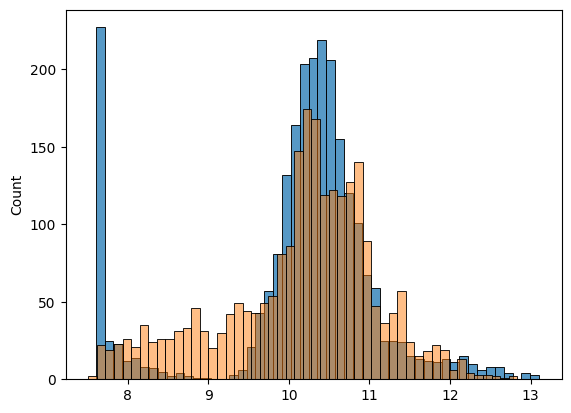

In [211]:
sns.histplot(y_val, bins = 50)
sns.histplot(y_pred, bins = 50, alpha = 0.5)

The yellow is the predicted value, while the blue is the validated value

## **Categorical Variales**

number_of_doors is categorical too


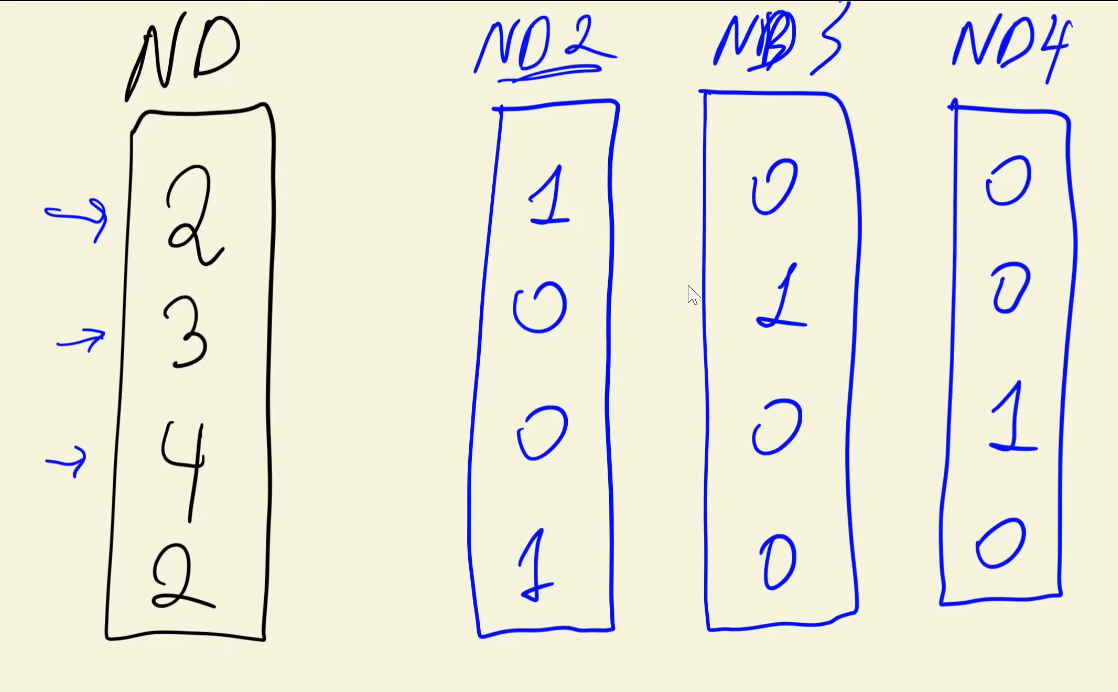

Creation of new three binary column to represent the number of doors. Note two is the lowest and 4 is the assumed highest

In [212]:
df_train.number_of_doors.unique()

array([ 4.,  2.,  3., nan])

In [213]:
# df_train['num_doors_2'] = (df_train.number_of_doors == 2).astype('int')
# df_train['num_doors_3'] = (df_train.number_of_doors == 3).astype('int')
# df_train['num_doors_4'] = (df_train.number_of_doors == 4).astype('int')

In [214]:
for  i in (2,3,4):
    df_train[f'num_doors_{i}'] = (df_train.number_of_doors == i).astype('int')

In [215]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,hyundai,elantra,2016,regular_unleaded,173.0,4.0,automatic,front_wheel_drive,4.0,performance,compact,sedan,35,24,1439,0,0,1
1,mazda,mx-5_miata,2015,premium_unleaded_(recommended),167.0,4.0,manual,rear_wheel_drive,2.0,performance,compact,convertible,28,22,586,1,0,0
2,audi,90,1995,regular_unleaded,172.0,6.0,manual,all_wheel_drive,4.0,luxury,compact,sedan,23,17,3105,0,0,1
3,hyundai,elantra_coupe,2013,regular_unleaded,145.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,coupe,37,27,1439,1,0,0
4,suzuki,aerio,2005,regular_unleaded,155.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,sedan,28,22,481,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,infiniti,m,2012,premium_unleaded_(required),330.0,6.0,automatic,all_wheel_drive,4.0,"luxury,performance",large,sedan,24,17,190,0,0,1
7146,subaru,brz,2017,premium_unleaded_(required),205.0,4.0,manual,rear_wheel_drive,2.0,performance,compact,coupe,29,21,640,1,0,0
7147,cadillac,ats,2015,flex-fuel_(unleaded/e85),321.0,6.0,automatic,rear_wheel_drive,4.0,"flex_fuel,luxury,high-performance",compact,sedan,28,18,1624,0,0,1
7148,volkswagen,jetta_gli,2013,premium_unleaded_(recommended),210.0,4.0,manual,front_wheel_drive,4.0,performance,midsize,sedan,33,22,873,0,0,1


#### Add the new feature to the current training dataset function

In [216]:
def prepare_X(df): 
    df = df.copy() # using a copy of df, because we do not prefer to create a new feature from a function
    features = base.copy() # we do not want to modify the base features

    df['age'] = 2017 -df.year # creating a new feature age, which is the difference between the latest year and the actual data
    features.append('age') # adding age to the numerical features base using append instead

    for  i in (2,3,4):
        df[f'num_doors_{i}'] = (df.number_of_doors == i).astype('int')
        features.append(f'num_doors_{i}')

    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [217]:
# 1. Find the X_train
X_train = prepare_X(df_train)

# 2. Solve for the weights and bias term
w0, w = train_linear_regression(X_train, y_train)

# 3. Prepare the X of the validation dataset
X_val = prepare_X(df_val)

# 4. Finding the predicted value
y_pred = X_val.dot(w)+ w0

# 5. Validating using RMSE
rmse(y_val, y_pred)

np.float64(0.502591356111675)

It is like there is no improvement at all.

Now, looking at the car's brand and checking the top 5 most popuar brand

In [218]:
list(df.make.value_counts().head().index)

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [219]:
## Adding the car brand to the function but converting them into multiple binary columns

makes = list(df.make.value_counts().head().index)

def prepare_X(df): 
    df = df.copy() # using a copy of df, because we do not prefer to create a new feature from a function
    features = base.copy() # we do not want to modify the base features

    df['age'] = 2017 -df.year # creating a new feature age, which is the difference between the latest year and the actual data
    features.append('age') # adding age to the numerical features base using append instead

    for  i in (2,3,4):
        df[f'num_doors_{i}'] = (df.number_of_doors == i).astype('int')
        features.append(f'num_doors_{i}')

    for i in makes:
        df[f'makes_{i}'] = (df.make == i).astype('int')
        features.append(f"makes_{i}")

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [220]:
# 1. Find the X_train
X_train = prepare_X(df_train)

# 2. Solve for the weights and bias term
w0, w = train_linear_regression(X_train, y_train)

# 3. Prepare the X of the validation dataset
X_val = prepare_X(df_val)

# 4. Finding the predicted value
y_pred = X_val.dot(w)+ w0

# 5. Validating using RMSE
rmse(y_val, y_pred)

np.float64(0.49634799569481347)

It improved for one percent

With this tiny bit of improvement we could also hope its effect if we try to insert the remaining categorical variables

In [221]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
num_doors_2            int64
num_doors_3            int64
num_doors_4            int64
dtype: object

In [222]:
categorical_variables = [
'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 
'market_category',  'vehicle_size', 'vehicle_style']

In [223]:
df_train.make.value_counts().head().index

Index(['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'], dtype='object', name='make')

In [224]:
categories = {}
for i in categorical_variables:

    categories[i] = (list(df_train[f'{i}'].value_counts().head().index))

In [225]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [226]:
for c, values in categories.items():
    print(c)
    for v in values:
        print(v)
        
    break


make
chevrolet
ford
volkswagen
toyota
dodge


In [227]:
## Adding all the categories (not just make) to the function but converting them into multiple binary columns
 
def prepare_X(df): 
    df = df.copy() # using a copy of df, because we do not prefer to create a new feature from a function
    features = base.copy() # we do not want to modify the base features

    df['age'] = 2017 -df.year # creating a new feature age, which is the difference between the latest year and the actual data
    features.append('age') # adding age to the numerical features base using append instead

    for  i in (2,3,4):
        df[f'num_doors_{i}'] = (df.number_of_doors == i).astype('int')
        features.append(f'num_doors_{i}')

    for c, values in categories.items():
        for v in values:
            df[f'{c}_{v}'] = (df[c] == v).astype('int')
            features.append(f'{c}_{v}')


    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [228]:
# 1. Find the X_train
X_train = prepare_X(df_train)

# 2. Solve for the weights and bias term
w0, w = train_linear_regression(X_train, y_train)

# 3. Prepare the X of the validation dataset
X_val = prepare_X(df_val)

# 4. Finding the predicted value
y_pred = X_val.dot(w)+ w0

# 5. Validating using RMSE
rmse(y_val, y_pred)

np.float64(28.995765700238408)

28?!

## **Regularization**
The method of controling the weights so that it would not get too big 

Sample matrix when two columns are similar

In [229]:
XTX = [
    [1,2,2],
    [2,1,1],
    [2,1,1]
]

XTX = np.array(XTX)

In [230]:
# Inverse the array
np.linalg.inv(XTX)

LinAlgError: Singular matrix

In [ ]:
# Add a very small number

XTX = [
    [1,2,2],
    [2,1,1.000001],
    [2,1.000001,1]
]

XTX = np.array(XTX)

In [ ]:
# Inverse the array
np.linalg.inv(XTX)

array([[-3.33333556e-01,  3.33333389e-01,  3.33333389e-01],
       [ 3.33333389e-01, -5.00000083e+05,  4.99999917e+05],
       [ 3.33333389e-01,  4.99999917e+05, -5.00000083e+05]])

Now you can see a very big number inside the array e+05, 

One way to fix the problem is to add small number to the diagonal of the array

In [ ]:
# Add a very small number

XTX = [
    [1.0001,2,2],
    [2,1.0001,1.000001],
    [2,1.000001,1.0001]
]

XTX = np.array(XTX)

# Inverse the array
np.linalg.inv(XTX)

array([[-3.33366891e-01,  3.33350057e-01,  3.33350057e-01],
       [ 3.33350057e-01,  5.05042170e+03, -5.05058840e+03],
       [ 3.33350057e-01, -5.05058840e+03,  5.05042170e+03]])

It went down to only e+03.

Note:
- The larger we have in the diagonal the lesser the inverse value is 

In [ ]:
# Remember the eye function

np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

Re-use this to add small number to the diagonal of the array

In [ ]:
XTX  = XTX + 0.01 * np.eye(3)
XTX

array([[1.0201  , 2.      , 2.      ],
       [2.      , 1.0201  , 1.000001],
       [2.      , 1.000001, 1.0201  ]])

In [ ]:
np.linalg.inv(XTX)

array([[ -0.34012471,   0.33674031,   0.33674031],
       [  0.33674031,  24.79098235, -24.96273674],
       [  0.33674031, -24.96273674,  24.79098235]])

In [ ]:
def train_linear_regression_reg(X, y, r=0.01): # regularizing the weights. Then adding one new parameter 'r' with a default value 0.01
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X) 

    XTX = XTX + r * np.eye(XTX.shape[0]) # adding the regularization

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

Using the new training function of weights with regularization

In [ ]:
# 1. Find the X_train
X_train = prepare_X(df_train)

# 2. Solve for the weights and bias term
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

# 3. Prepare the X of the validation dataset
X_val = prepare_X(df_val)

# 4. Finding the predicted value
y_pred = X_val.dot(w)+ w0

# 5. Validating using RMSE
rmse(y_val, y_pred)

np.float64(0.4476560929942146)

The last good rmse is np.float64(0.49634799569481347). thus 0.44 is a considerable improvement


However, what is the best value for r? 

## **Finding the best r**

Answer: Use the validation set to find the best value

In [ ]:
for i in [0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001, 0.00000001 ] :
    # 1. Find the X_train
    X_train = prepare_X(df_train)

    # 2. Solve for the weights and bias term
    w0, w = train_linear_regression_reg(X_train, y_train, r=i)

    # 3. Prepare the X of the validation dataset
    X_val = prepare_X(df_val)

    # 4. Finding the predicted value
    y_pred = X_val.dot(w)+ w0

    # 5. Validating using RMSE
    score = rmse(y_val, y_pred)
    print(i, score)

0.1 0.44771090780602574
0.01 0.4476560929942146
0.001 0.44765192462265774
0.0001 0.4476515235840386
1e-05 0.4476514924071753
1e-06 0.44765173900080313
1e-08 0.4476804834836642


There is not much difference apparently

In [ ]:
i = 0.001

# 1. Find the X_train
X_train = prepare_X(df_train)

# 2. Solve for the weights and bias term
w0, w = train_linear_regression_reg(X_train, y_train, r=i)

# 3. Prepare the X of the validation dataset
X_val = prepare_X(df_val)

# 4. Finding the predicted value
y_pred = X_val.dot(w)+ w0

# 5. Validating using RMSE
score = rmse(y_val, y_pred)
print(i, score)

0.001 0.44765192462265774


## **Training the final model**

Remember:

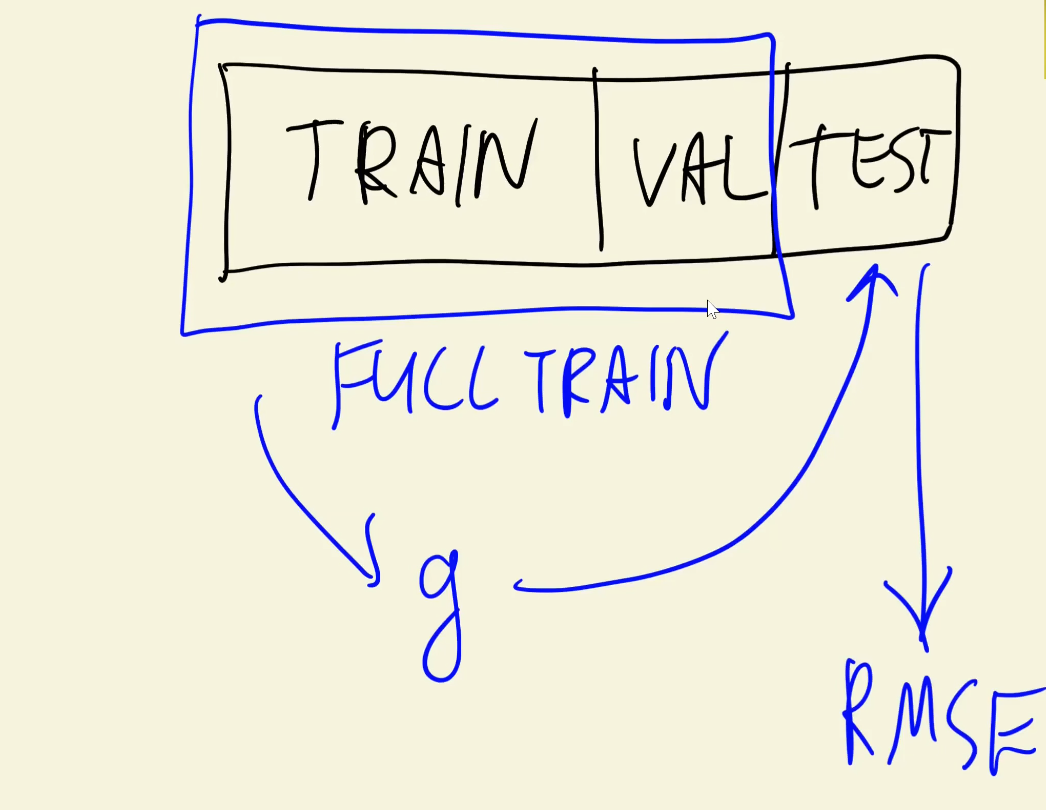

In [232]:
# combine the two dataframe
df_full_train = pd.concat([df_train, df_val])

In [234]:
df_full_train = df_full_train.reset_index(drop=True)

In [236]:
df_full_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,hyundai,elantra,2016,regular_unleaded,173.0,4.0,automatic,front_wheel_drive,4.0,performance,compact,sedan,35,24,1439,0.0,0.0,1.0
1,mazda,mx-5_miata,2015,premium_unleaded_(recommended),167.0,4.0,manual,rear_wheel_drive,2.0,performance,compact,convertible,28,22,586,1.0,0.0,0.0
2,audi,90,1995,regular_unleaded,172.0,6.0,manual,all_wheel_drive,4.0,luxury,compact,sedan,23,17,3105,0.0,0.0,1.0
3,hyundai,elantra_coupe,2013,regular_unleaded,145.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,coupe,37,27,1439,1.0,0.0,0.0
4,suzuki,aerio,2005,regular_unleaded,155.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,sedan,28,22,481,0.0,0.0,1.0


In [237]:
# prepare the feature (X) matrix
X_full_train = prepare_X(df_full_train)
X_full_train

array([[173.,   4.,  35., ...,   0.,   0.,   0.],
       [167.,   4.,  28., ...,   0.,   1.,   0.],
       [172.,   6.,  23., ...,   0.,   0.,   0.],
       ...,
       [200.,   4.,  25., ...,   1.,   0.,   0.],
       [101.,   4.,  40., ...,   0.,   0.,   0.],
       [185.,   4.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [238]:
# merging the two y variables from the two dataframe

y_full_train = np.concatenate([y_train, y_val])
y_full_train

array([ 9.96415923, 10.08460005,  7.60140233, ...,  7.63964229,
        9.83633228,  7.60140233], shape=(9532,))

In [ ]:
i = 0.001

# 1. Find the X_train

# 2. Solve for the weights and bias term
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=i)

# 3. Prepare the X of the testing dataset
X_test = prepare_X(df_test)

# 4. Finding the predicted value
y_pred = X_test.dot(w)+ w0

# 5. Validating using RMSE
score = rmse(y_test, y_pred)
print(i, score)

0.001 0.4587898048156762


## **Using the machine learning model**

In [240]:
df_test.iloc[16]

make                              toyota
model                             tacoma
year                                2015
engine_fuel_type        regular_unleaded
engine_hp                          159.0
engine_cylinders                     4.0
transmission_type                 manual
driven_wheels           rear_wheel_drive
number_of_doors                      4.0
market_category                      NaN
vehicle_size                     compact
vehicle_style        extended_cab_pickup
highway_mpg                           25
city_mpg                              21
popularity                          2031
Name: 16, dtype: object

In [242]:
# convert it to dictionary

car = df_test.iloc[16].to_dict()
car

{'make': 'toyota',
 'model': 'tacoma',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 159.0,
 'engine_cylinders': 4.0,
 'transmission_type': 'manual',
 'driven_wheels': 'rear_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'compact',
 'vehicle_style': 'extended_cab_pickup',
 'highway_mpg': 25,
 'city_mpg': 21,
 'popularity': 2031}

In [244]:
df_small = pd.DataFrame([car]) 
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,tacoma,2015,regular_unleaded,159.0,4.0,manual,rear_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,21,2031


In [ ]:
# prepare the feature (X) matrix
X_small = prepare_X(df_small)

# Find the predicted value
y_pred = X_small.dot(w)+ w0

# Getting the index 0
y_pred = y_pred[0]

# Getting the real price
np.expm1(y_pred)

np.float64(19235.363465715884)

It cost around 19,235 USD

But, let's check and compare it to the actual value

In [251]:
actual_price = y_test[16]
np.expm1(actual_price)

np.float64(20965.000000000015)

The difference between the predicted and the actual value is only around 1800. Not bad for starter